## Detección de puntos clave a través de pose estimation
En este ejercicio detectaremos los brazos de las personas a través de un modelo que estima la postura de las personas.
Formato MPII
*   0 - Cabeza
*   1 - Cuello
*   2 - Hombro Derecho
*   3 - Codo Derecho
*   4 - Muñeca Derecha
*   5 - Hombro Izquierdo
*   6 - Codo Izquierdo
*   7 - Muñeca Izquierda
*   8 - Cadera Derecha
*   9 - Rodilla Derecha
*   10 - Tobillo Derecho
*   11 - Cadera Izquierda
*   12 - Rodilla Izquierda
*   13 - Tobillo Izquierdo
*   14 - Pecho
*   15 - Fondo

Autores: Zhe Cao et al.
Fuente del artículo: https://arxiv.org/pdf/1611.08050.pdf

In [8]:
# Importación de las librerías
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Reconstrucción del modelo

In [9]:
# Lectura del archivo de configuración y archivo de pesos.
#ruta =
configFile = '/content/model/pose_deploy_linevec.prototxt'    # archivo de configuración
weightsFile = '/content/model/pose_iter_160000.caffemodel'  # archivo con los pesos del modelo

In [10]:
import os
print(os.path.exists("/content/model/pose_iter_160000.caffemodel"))
print(os.path.getsize("/content/model/pose_iter_160000.caffemodel"))

True
205950363


In [11]:
# Inicialización del modelo con los archivos de configuración y pesos
modelo = cv2.dnn.readNetFromCaffe(configFile, weightsFile)

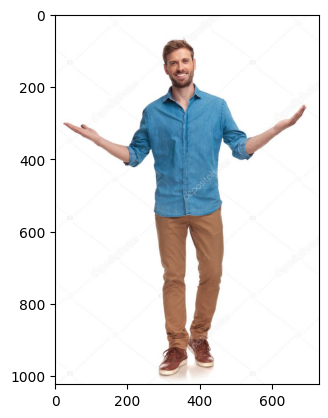

In [88]:
# Lectura de una imagen y visualización
img = cv2.imread("fullBody.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img, cmap='Accent')
plt.show()

In [89]:
# Tamaño de las imágenes
ANCHO = img.shape[1]
ALTO = img.shape[0]
print(f"Ancho: {ANCHO}, Alto: {ALTO}")

Ancho: 731, Alto: 1023


In [90]:
# Preprocesamiento de la imágen a través de blob from image
# (1, 3, 368, 368) 1= la key extra, 3= canales, 368x368= tamaño
imgBlob = cv2.dnn.blobFromImage(img, scalefactor=1/255, size=(368,368), swapRB=True)
imgBlob.shape

(1, 3, 368, 368)

In [91]:
# Generando una inferencia con el modelo
# El resultado contiene:
# (ID de la imagen, keypoints e affinity parts, height, width)
# (1, 44, 46, 46) 44= # de matrices

modelo.setInput(imgBlob)
output = modelo.forward()
output.shape

(1, 44, 46, 46)

Procesamiento de la salida del modelo

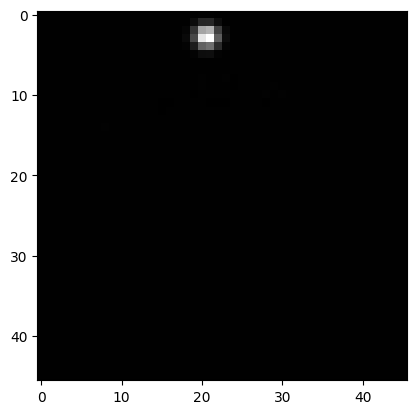

In [92]:
# Análisis de la salida
plt.imshow(output[0,0], cmap='gray')
plt.show()

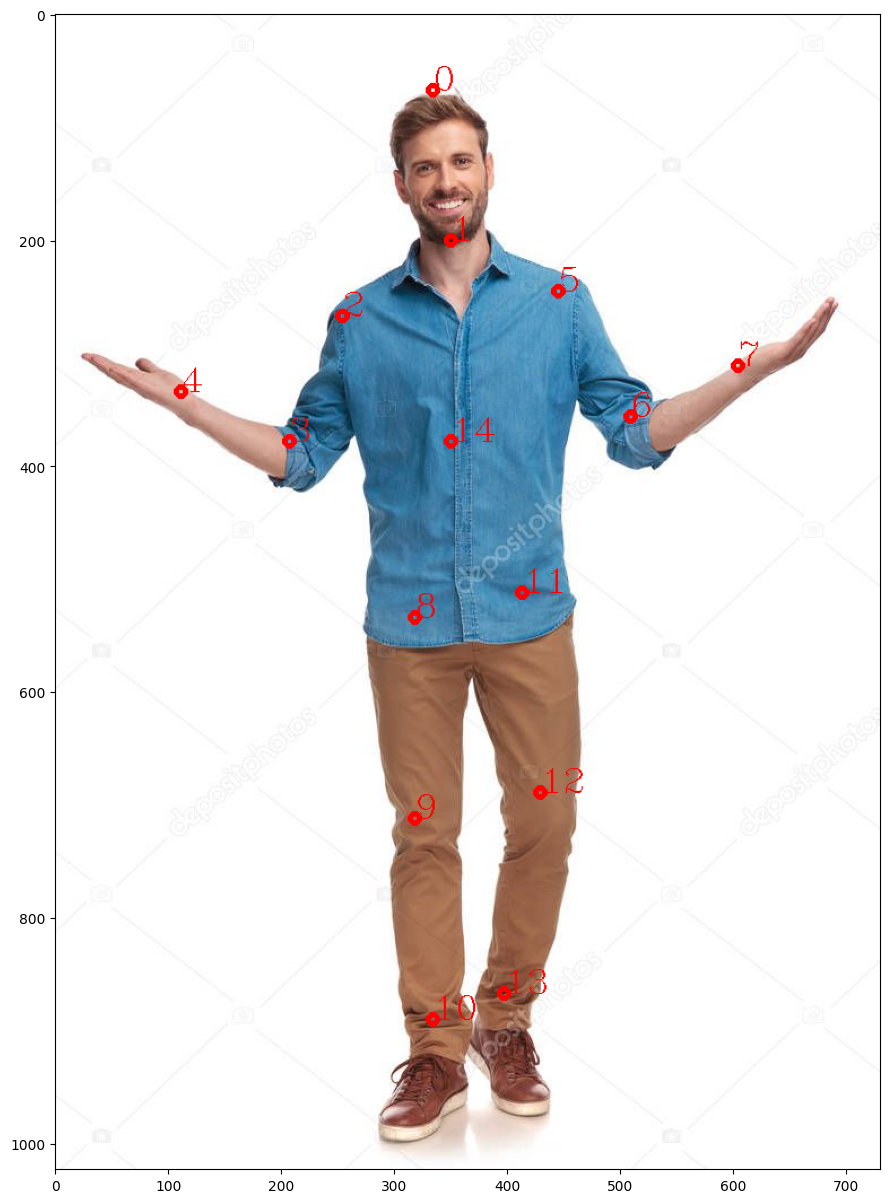

In [93]:
h = output.shape[2]   # alto de la imágen de salida
w = output.shape[3]   # ancho de la imágen de salida
locAllPuntos = []

img_copy = np.copy(img)

for i in range(15):
  # Mapa con los scores de confianza de las partes del cuerpo:
  probMap = output[0, i, :, :]

  # Encontramos el máximo global del probMap.
  minV, maxV, minP, maxP = cv2.minMaxLoc(probMap)

  # Escalamos los puntos al tamaño original de la imágen
  x = round((maxP[0]/w) * ANCHO)
  y = round((maxP[1]/h) * ALTO)

  # Colocamos las anotaciones sobre la imágen
  cv2.circle(img_copy, (x,y), 4, (255,0,0), 3)
  cv2.putText(img_copy, str(i), (x, y), cv2.FONT_HERSHEY_COMPLEX, 1, (255,0,0), 1)
  locAllPuntos.append((x, y))


plt.figure(figsize=(15, 15))
plt.imshow(img_copy)
plt.show()

## Reto 1: detectar si la persona tiene las manos arriba

Tiene las manos abajo


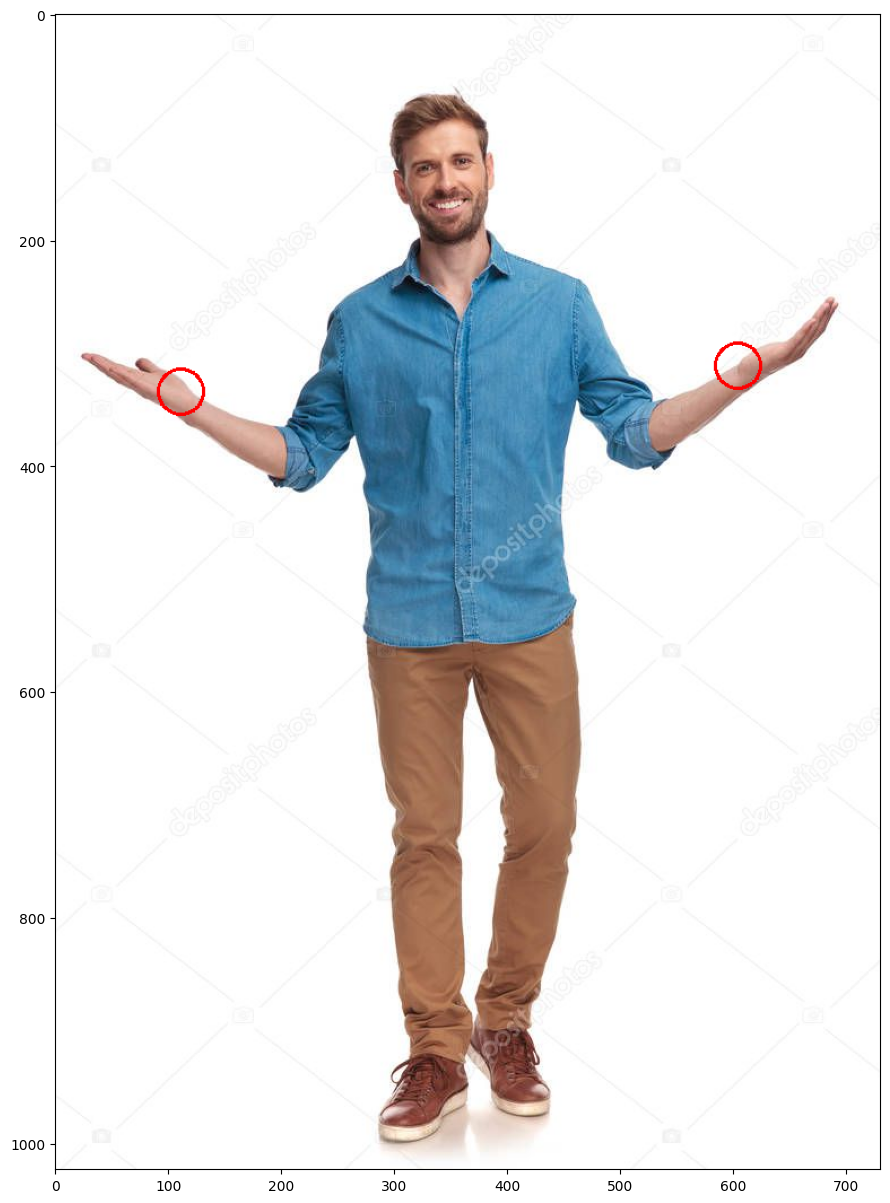

In [94]:
# Estos son los puntos clave
# 0 - Cabeza
# 1 - Cuello
# 4 - Muñeca derecha
# 7 - Muñeca izquierda
puntosClave = [0, 1, 4, 7]
locPuntos = []

for i in puntosClave:
  probMap = output[0, i, :, :]
  minV, maxV, minP, maxP = cv2.minMaxLoc(probMap)
  h = output.shape[2]
  w = output.shape[3]
  x = round((ANCHO/w) * maxP[0])
  y = round((ALTO/h) * maxP[1])
  locPuntos.append((x,y))

# Validación de la postura de las manos
if (locPuntos[2][1] < locPuntos[1][1]) and (locPuntos[3][1] < locPuntos[1][1]):
  color = (0, 255, 0)
  print('Tiene las manos arriba')
else:
  color = (255, 0, 0)
  print('Tiene las manos abajo')

# Visualización de los resultados
img_copy2 = np.copy(img)
cv2.circle(img_copy2, (locPuntos[2][0], locPuntos[2][1]), 20, color, thickness=2)
cv2.circle(img_copy2, (locPuntos[3][0], locPuntos[3][1]), 20, color, thickness=2)
plt.figure(figsize=(15, 15))
plt.imshow(img_copy2)
plt.show()

## Reto 2: dibujar el esqueleto

0 - Cabeza

1 - Cuello

2 - Hombro Derecho

3 - Codo Derecho

4 - Muñeca Derecha

5 - Hombro Izquierdo

6 - Codo Izquierdo

7 - Muñeca Izquierda

8 - Cadera Derecha

9 - Rodilla Derecha

10 - Tobillo Derecho

11 - Cadera Izquierda

12 - Rodilla Izquierda

13 - Tobillo Izquierdo

14 - Pecho

15 - Fondo

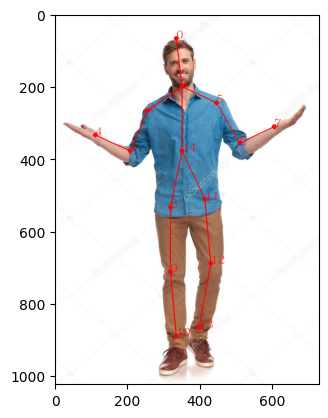

In [98]:
img_esqueleto = np.copy(img_copy)

# Array de lineas de cuerpo
POSE_PAIRS = [
    (0, 1),
    (1, 2),
    (1, 5),
    (5, 6),
    (2, 3),
    (3, 4),
    (6, 7),
    (1, 14),
    (14, 8),
    (8, 9),
    (9, 10),
    (14, 11),
    (11, 12),
    (12, 13)
]

for partA, partB in POSE_PAIRS:

    # Validar que los índices existan en la lista
    if partA >= len(locAllPuntos) or partB >= len(locAllPuntos):
        continue

    # Validar que el punto no sea None
    if locAllPuntos[partA] is None or locAllPuntos[partB] is None:
        continue

    cv2.line(
        img_esqueleto,
        locAllPuntos[partA],
        locAllPuntos[partB],
        (255, 0, 0),
        2
    )

plt.imshow(img_esqueleto)
plt.show()